In [4]:
# Importamos las librerías
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import date, datetime, time, timezone

In [5]:
# Definimos una función para obtener datos de acciones de yahoo finance
def get_stock_data(ticker, start_date, end_date):
    # Descargar los datos del ticker de inicio y fin
    data = yf.download(tickers=[ticker], start= start_date, end=end_date, multi_level_index=False)
    # Insertar una columan 'ticker', al inicio del Dataframe con el nombre del ticker.
    data.insert(0, "Ticker", ticker)

    return data

    

In [6]:
# Definir el símbolo de la acción (ticker) para Disney
ticker = 'DIS'
# La fecha de inicio para la descarga de datos:
start = datetime (2020, 1, 1)
# La fecha de fin como la fecha actual
end = datetime.today()

In [7]:
# Obtenemos los datos de las acciones de Disney
d = get_stock_data(ticker,start,end)
d.head()

[*********************100%***********************]  1 of 1 completed


,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,DIS,144.790253,144.790253,141.761586,141.947202,9502100
2020-01-03,DIS,143.129379,144.497163,142.689736,143.031674,7320200
2020-01-06,DIS,142.298965,142.670227,140.989799,142.191496,8262500
2020-01-07,DIS,142.347794,143.490873,142.074237,142.631130,6906500
2020-01-08,DIS,142.054688,142.767903,141.488045,142.142628,6984200


In [8]:
# Debido a que el analisis se basa solo en el precio de cierre por cada accion.
# Date como indice, ticker como columna 
d = d.reset_index().pivot(index="Date", columns="Ticker", values="Close")
d.head()

Ticker,DIS
Date,
2020-01-02,144.790253
2020-01-03,143.129379
2020-01-06,142.298965
2020-01-07,142.347794
2020-01-08,142.054688


In [9]:
# Obtener los datos de acciones vara varios ETFs (SPY, IYW, VT, DBA, TLT, PDBC, IAU)
SPY = get_stock_data('SPY', start, end)
IYW = get_stock_data("IYW", start, end)
VT = get_stock_data("VT", start, end)
DBA = get_stock_data("DBA", start, end)
TLT = get_stock_data("TLT", start, end)
PDBC = get_stock_data("PDBC", start, end)
IAU = get_stock_data("IAU", start, end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [10]:
# Mostramos uns resumen informativo del Dataframe 'SPY'.
SPY.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1623 entries, 2020-01-02 to 2026-06-17
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  1623 non-null   str    
 1   Close   1623 non-null   float64
 2   High    1623 non-null   float64
 3   Low     1623 non-null   float64
 4   Open    1623 non-null   float64
 5   Volume  1623 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 88.8 KB


In [11]:
# Reestrucutrar cada Dataframe de ETF individualmente
# Esto transforma cada Dataframe para que 'Date' sea el indice,
# 'Ticker' la columna y 'Close' los valores.
SPY = SPY.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IYW = IYW.reset_index().pivot(index="Date", columns="Ticker", values="Close")
VT = VT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
DBA = DBA.reset_index().pivot(index="Date", columns="Ticker", values="Close")
TLT = TLT.reset_index().pivot(index="Date", columns="Ticker", values="Close")
PDBC = PDBC.reset_index().pivot(index="Date", columns="Ticker", values="Close")
IAU = IAU.reset_index().pivot(index="Date", columns="Ticker", values="Close")

In [12]:
# Concatenar todos los DF reestrucutrados de ETFs en un único DF llamado 'stock'.
# 'axis=1' indica que la concatenación es por columnas.
# 'join='outer'' asegura que todas las fechas estén presentes.
# rellenamos con NaN si algún activo no tiene datos para una fecha concreta.
stock = pd.concat([SPY, IYW, VT, DBA, TLT, PDBC, IAU], axis=1, join='outer')
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888184,57.811764,72.245468,14.560220,113.300850,8.430121,29.219999
2020-01-03,294.640106,57.234680,71.591988,14.392557,115.045769,8.501048,29.620001
2020-01-06,295.764160,57.587753,71.856941,14.427855,114.392479,8.511180,29.920000
2020-01-07,294.932526,57.609665,71.636154,14.463152,113.830109,8.495982,30.040001
2020-01-08,296.504303,58.184319,71.927574,14.392557,113.077568,8.379460,29.820000


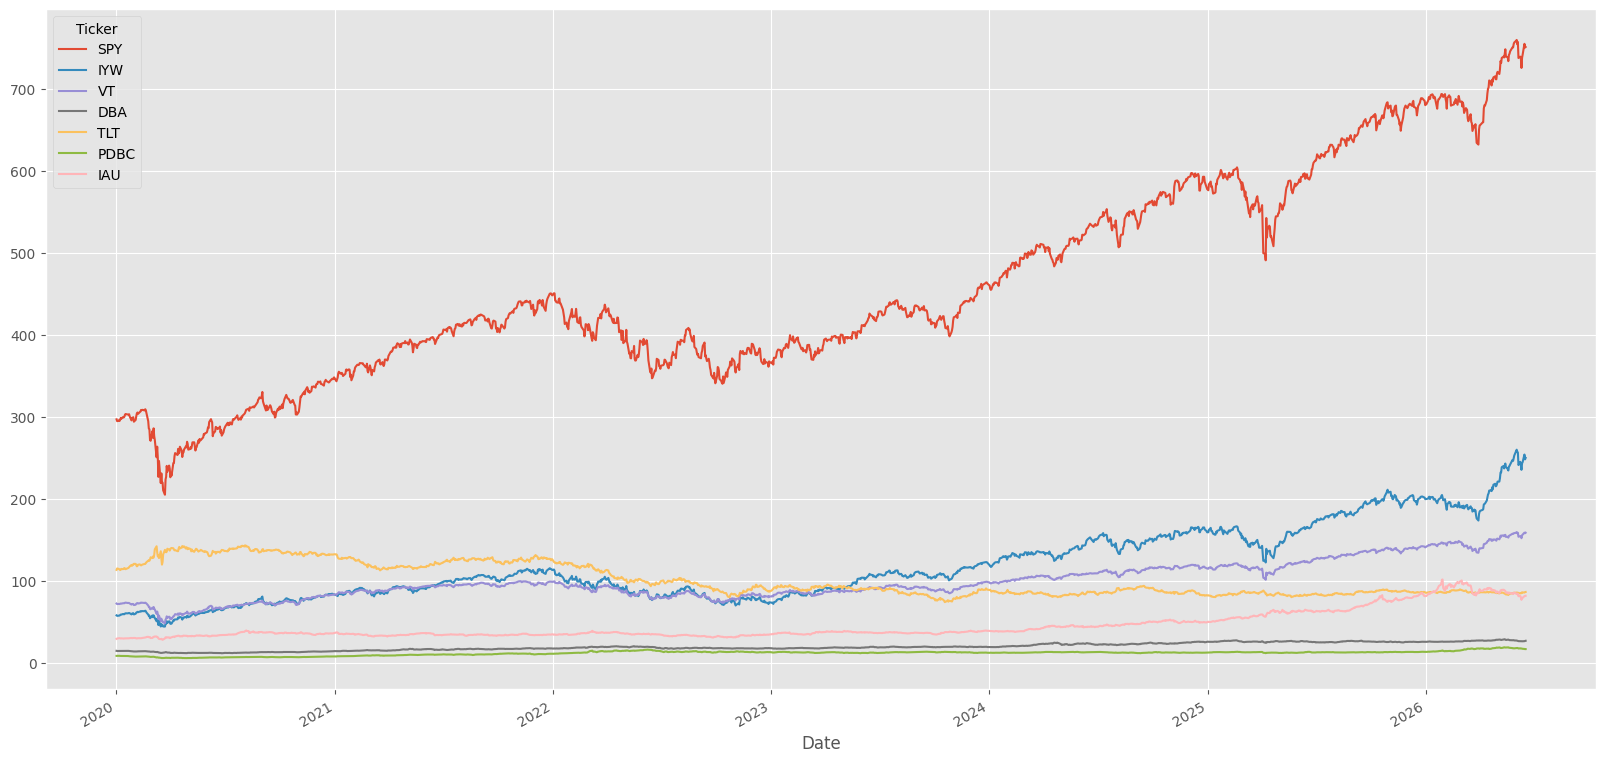

In [13]:
# Establecer el estilo de las gráficas a 'ggplot' para una apariencia estética específica
plt.style.use('ggplot')
# Graficar los precios de cierre de todos los activos en el DF 'stock'
# 'figsize' definir el tamaño de la figura(ancho,alto)
stock.plot(figsize=(20, 10))
plt.show()

# Esta gráfica muestra la evolución de los precios de cierre de varios activos financieros
# (SPY, IYW, ...) a lo largo del tiempo
# Podemo observar tendencias generales, picos y caídas. Por lo que podemos afirmar
# que hay una volatilidad vigente del activo durante todo el rango de tiempo analizado.


In [14]:
# Filtrar el DF 'stock' en la época covid.
covid = stock['2020-2-1':'2020-7-31']
covid.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-02-03,296.202759,59.835262,70.797226,13.783675,120.554718,7.543540,30.120001
2020-02-04,300.717285,61.211025,71.962914,13.810148,118.931160,7.553672,29.719999
2020-02-05,304.190002,61.481316,72.616386,13.818973,117.630722,7.660062,29.760000
2020-02-06,305.213531,62.148510,72.845978,13.916041,118.160843,7.695525,29.940001
2020-02-07,303.586792,61.680992,72.254318,13.977812,119.635262,7.660062,30.000000


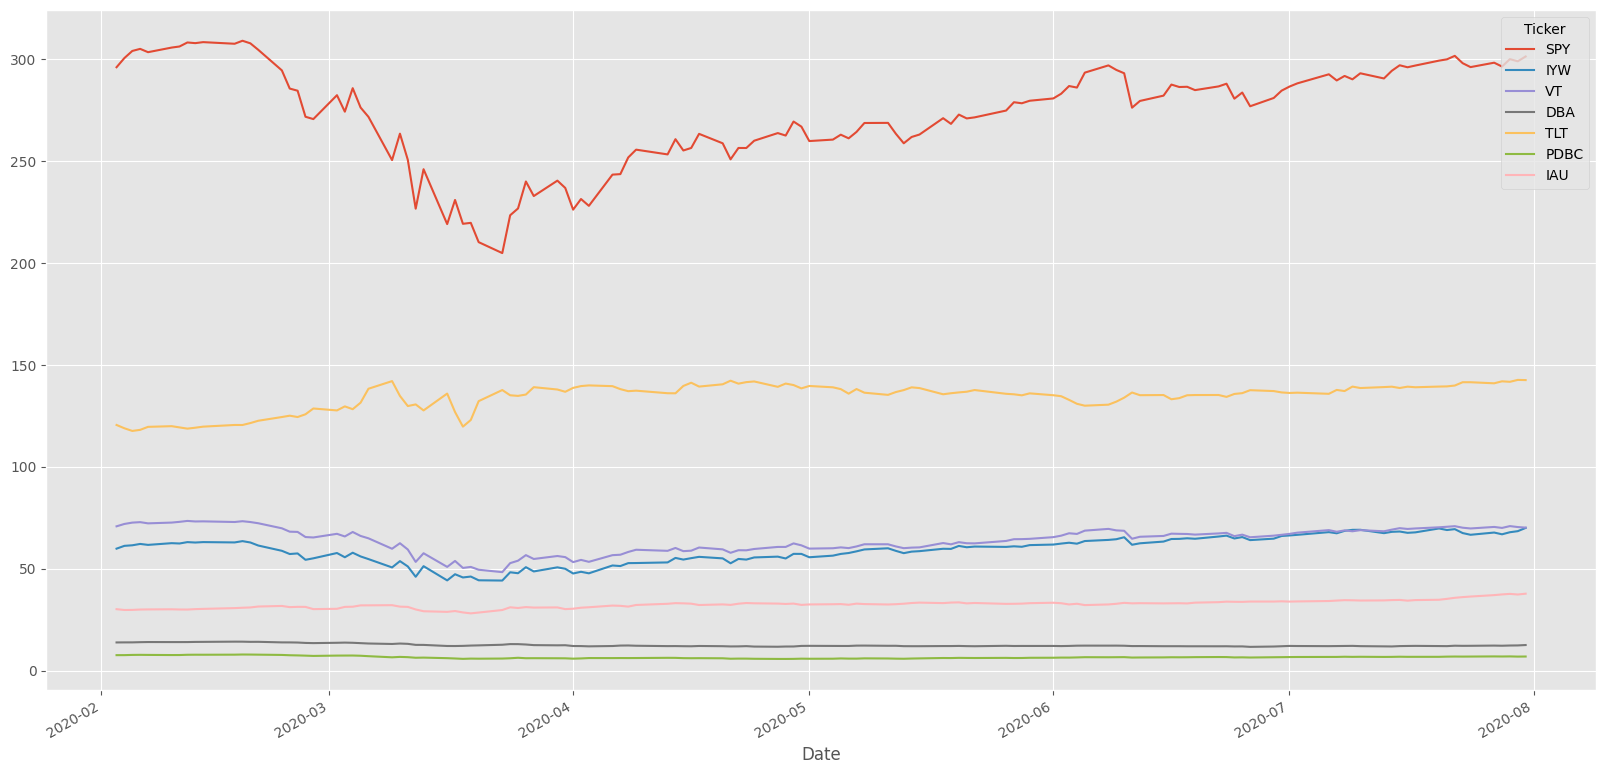

In [15]:
plt.style.use('ggplot')
# Graficar los precios de cierre de todos los activos en el DF 'covid'
covid.plot(figsize = (20, 10))
plt.show()
# Esta gráfica se enfoca en el rendimiento de los mismos activos pero durante 
# el periodo de la pandemia COVID-19.
# Es particularmente interesante observar cómo la mayoría de los activos experimentaron
# una caída brutal al inicio de la pandemia, seguida de una recuperación global, 


In [16]:
# Extraer el índice de fechas del DF 'covid' para usarlo como eje x en las gráficas.
x = covid.index

# Crear series de Pandas para los precios de cierre de 'SPY', 'IAU', 'DBA' y 'TLT' del
# DF 'covid'
s_y = covid['SPY']
i_y = covid["IAU"]
d_y = covid["DBA"]
t_y = covid["TLT"]


Text(0.5, 0.98, 'Covid 19')

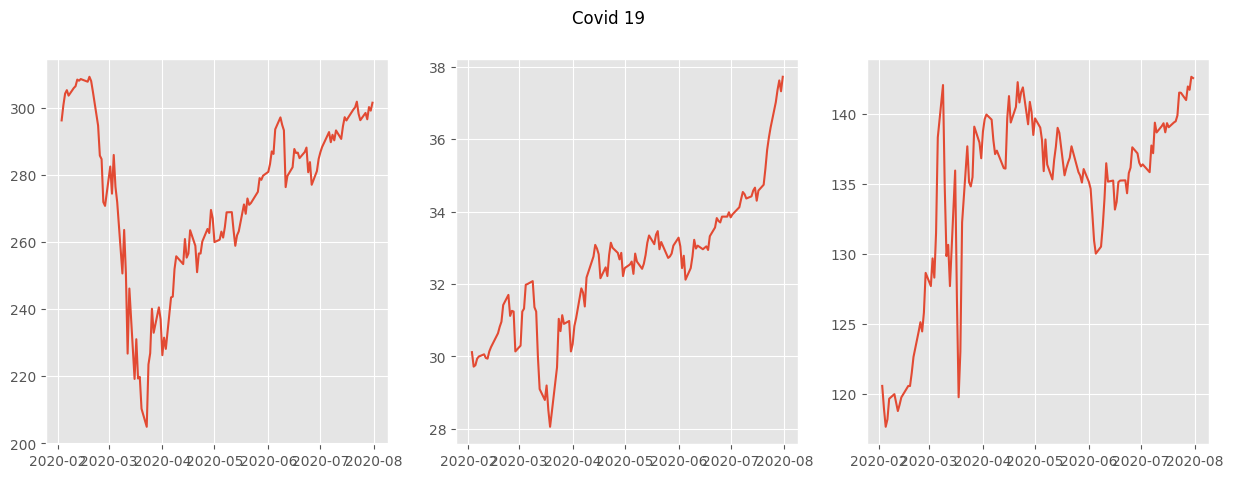

In [17]:
# Crear una figura con una cuadrícula de subplots de 1 fila y 3 columnas.
# y definimos su tamaño.
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
# Graficamos los precios del 'SPY' en el primer subplot
axs[0].plot(x, s_y)
# Graficamos los precios del 'IAU' en el primer subplot
axs[1].plot(x, i_y)
# Graficamos los precios del 'TLT' en el primer subplot
axs[2].plot(x, t_y)

fig.suptitle('Covid 19')

In [18]:
# Definnir el símbolo de la acción (ticker) como 'PDBC'.
ticker = 'PDBC'
# Establecer la fecha de inicio para la descarga de datos 
start = datetime(2020, 1, 1)
# Establecemos el final
end = datetime.today()


In [19]:
# Obtener los datos de las acciones para el ticker 'PDBC' 
df = get_stock_data(ticker, start, end)
df.head()


[*********************100%***********************]  1 of 1 completed


,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,PDBC,8.430122,8.445321,8.369329,8.394659,4004600
2020-01-03,PDBC,8.501048,8.531445,8.465584,8.516246,760200
2020-01-06,PDBC,8.511180,8.566908,8.495982,8.561842,1608700
2020-01-07,PDBC,8.495981,8.511179,8.469130,8.485849,1723200
2020-01-08,PDBC,8.379459,8.495981,8.289788,8.495981,923300


In [20]:
# Eliminamos las columnas: 'ticker', 'close', 'high', 'low, 'Open'
df.drop(['Ticker', 'High', 'Low', 'Open', 'Close'], axis=1, inplace=True)

In [21]:
# Mostramos las 5 primeras filas del DF despues de la eliminación.
df.head()

,Volume
Date,
2020-01-02,4004600
2020-01-03,760200
2020-01-06,1608700
2020-01-07,1723200
2020-01-08,923300


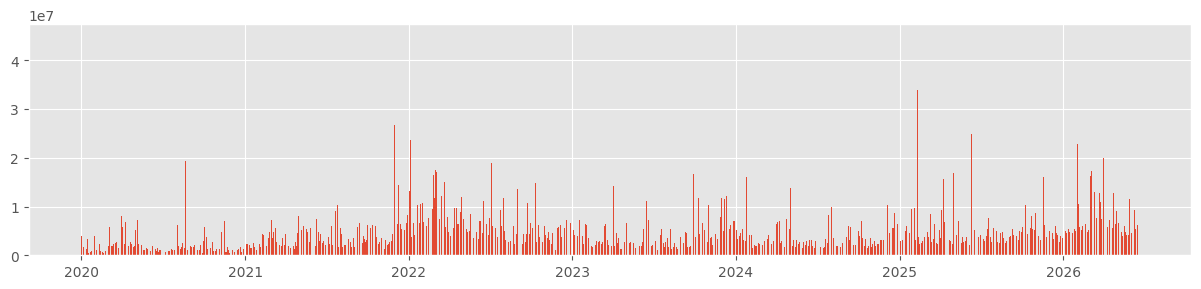

In [22]:
# Asiganar el índice del DF (date) a la variable 'x'
x = df.index
# Asignar la columna 'Volume' a la variable 'y'
y = df['Volume']

# Crear un nuevo plano para la gráfica con un tamaño específico
plt.figure(figsize=(15,3))
# Crear un gráfico de barras con las fechas en el eje x y el volumen en el eje y.
plt.bar(x, y)
# Mostramos el gráfico
plt.show()

# Esta gráfica de barras representa el volumen de negociación del ETF PDBC a lo largo
# del tiempo


In [23]:
# Obtener nuevamente los datos de las acciones para 'PDBC'
ticker = 'PDBC'
# Establecemos la fecha de inicio
start = datetime(2020,1,1)
# Establecemos fecha de fin
end = datetime.today()
df = get_stock_data(ticker, start, end)


[*********************100%***********************]  1 of 1 completed


In [24]:
df.head()

,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,PDBC,8.430121,8.445320,8.369328,8.394658,4004600
2020-01-03,PDBC,8.501048,8.531445,8.465584,8.516246,760200
2020-01-06,PDBC,8.511180,8.566908,8.495982,8.561842,1608700
2020-01-07,PDBC,8.495981,8.511179,8.469130,8.485849,1723200
2020-01-08,PDBC,8.379459,8.495981,8.289788,8.495981,923300


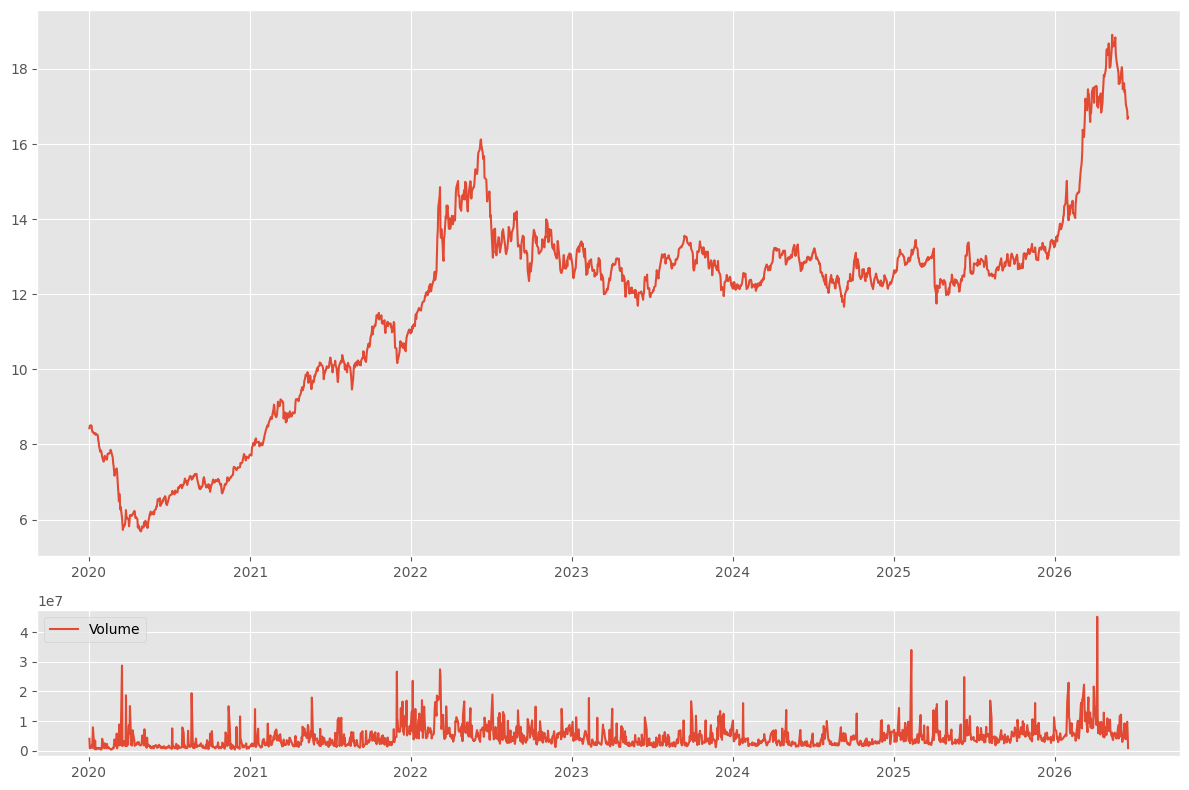

In [25]:
# Creamos una figura para la gráfica con un tamaño de 12x8 pulgadas
fig = plt.figure(figsize=(12,8))
# Definimos el 1º subplot en una cuadricula 4x4, ocupando las primeras 3 filas y 4 columnas.
top_grid = plt.subplot2grid((4,4), (0,0), rowspan=3, colspan=4)
# Definimos el 2º subplot en la misma cuadrícula, ocupando la última fila y 4 columnas.
bottom_grid = plt.subplot2grid((4,4), (3,0), rowspan=1, colspan=4)

# Graficar el precio de cierre en el subplot superior.
top_grid.plot(df.index, df['Close'], label='Close')
# Graficar el volumen en el subplot inferior
bottom_grid.plot(df.index, df['Volume'], label='Volume')

#Ajustamos automaticamente los parametros del subplot para que encaje bien en la figura
plt.tight_layout()

# Mostramos la leyenda
plt.legend()

# Mostramos el grafico
plt.show()

# Esta figura combina precio de cierre y volumen de negociacion de ETF PDBC
# en 2 subgraficos alienados. El grafico superior muestra la evolucion del precio de cierre
# mientras que el grafico inferior muestra el volumen.
# Podemos llegar a ala conclusion que se nota cuando hay una subida o bajada brusca del precio
# el volumen crece de manera sustancial.

In [26]:
# Mostrar las primeras 5 filas del DF 'stock'
stock.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,296.888184,57.811764,72.245468,14.560220,113.300850,8.430121,29.219999
2020-01-03,294.640106,57.234680,71.591988,14.392557,115.045769,8.501048,29.620001
2020-01-06,295.764160,57.587753,71.856941,14.427855,114.392479,8.511180,29.920000
2020-01-07,294.932526,57.609665,71.636154,14.463152,113.830109,8.495982,30.040001
2020-01-08,296.504303,58.184319,71.927574,14.392557,113.077568,8.379460,29.820000


In [27]:
# Mostramos la columna 'SPY'
stock['SPY']

Date
2020-01-02    296.888184
2020-01-03    294.640106
2020-01-06    295.764160
2020-01-07    294.932526
2020-01-08    296.504303
                 ...    
2026-06-11    737.760010
2026-06-12    741.750000
2026-06-15    754.830017
2026-06-16    750.330017
2026-06-17    750.989990
Name: SPY, Length: 1623, dtype: float64

In [28]:
# Mostrar la columna 'SPY', pero con los valores desplazaados en una posicion hacia abajo
# Esto es útil para calcular cambios respecto al día anterior
stock['SPY'].shift(1)

Date
2020-01-02           NaN
2020-01-03    296.888184
2020-01-06    294.640106
2020-01-07    295.764160
2020-01-08    294.932526
                 ...    
2026-06-11    725.429993
2026-06-12    737.760010
2026-06-15    741.750000
2026-06-16    754.830017
2026-06-17    750.330017
Name: SPY, Length: 1623, dtype: float64

In [29]:
# Calcular el cambio porcentual diario para el activo 'SPY'
# La fórmula es (Precio Actual / Precio Anterior - 1) * 100
spy_daily_pc = (stock['SPY'] / stock['SPY'].shift(1)- 1) * 100

In [30]:
# Mostramos los cambios porcentuales diarios calculados para 'SPY'
spy_daily_pc

Date
2020-01-02         NaN
2020-01-03   -0.757213
2020-01-06    0.381501
2020-01-07   -0.281182
2020-01-08    0.532928
                ...   
2026-06-11    1.699684
2026-06-12    0.540825
2026-06-15    1.763400
2026-06-16   -0.596161
2026-06-17    0.087958
Name: SPY, Length: 1623, dtype: float64

<Axes: xlabel='Date'>

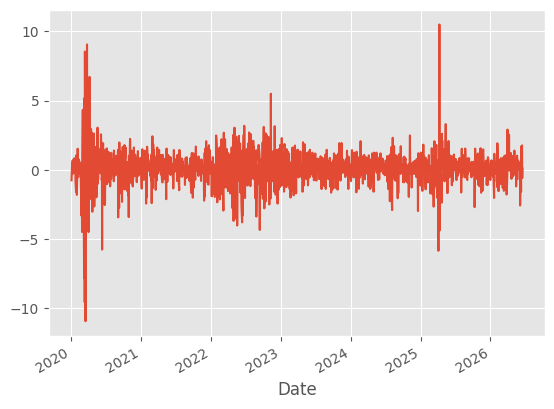

In [31]:
# Graficar los cambios porcentuales diarios para 'SPY'
spy_daily_pc.plot()

In [32]:
# Establecer el primer valor de 'spy_daily_pc' a 0.
# Esto es común ya que el primer día no tiene un dia anterior para poder aplicar formula
# del cambio porcentual.
spy_daily_pc.iloc[0] = 0

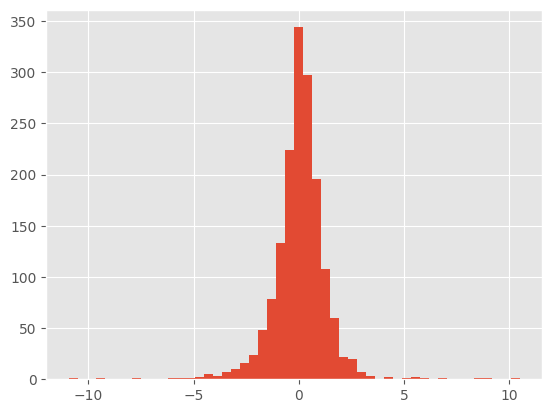

In [33]:
# Crear un histograma de los cambios porcentules diarios de 'SPY' con 50 bins (barras)
plt.hist(spy_daily_pc, bins=50)
# Mostramos el grafico
plt.show()

# El histogrmaa ilustra la distribución de los cambios porcentuales diarios del SPY
# Nos muestra con que frecuencia el precio del SPY sube o baja en un cierto porcentaje.
# Tipicamente estas distribuciones son simetricas alrededor de 0, indicando que 
# pequeños cambios son mas comunes que grandes cambios, y la cola de la distribución
# nos da una pequeña idea de la probabilidad de movimientros extremos en el mercado.

In [34]:
# Calcular el cambio porcentual diario para todas las columans del DF 'stock'
stock_daily_pc = (stock - stock.shift(1)) / stock.shift(1) * 100

In [35]:
# Mostramos las primeras 5 filas
stock_daily_pc.head()

Ticker,SPY,IYW,VT,DBA,TLT,PDBC,IAU
Date,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.757213,-0.998211,-0.904528,-1.151512,1.540076,0.841348,1.368931
2020-01-06,0.381501,0.616887,0.370088,0.245248,-0.567852,0.119183,1.012827
2020-01-07,-0.281182,0.038049,-0.307259,0.244648,-0.491615,-0.178562,0.401072
2020-01-08,0.532928,0.997495,0.406806,-0.488101,-0.661109,-1.371493,-0.732361


In [40]:
# Calcular la suma acumulada de los cambios porcentuales diarios para cada activo
# Esto representa el retorno acumulado a lo largo del tiempo
stock_d_cr = stock_daily_pc.cumsum()

In [37]:
stock_d_cr

<bound method DataFrame.cumsum of Ticker           SPY       IYW        VT       DBA       TLT      PDBC  \
Date                                                                     
2020-01-02       NaN       NaN       NaN       NaN       NaN       NaN   
2020-01-03 -0.757213 -0.998211 -0.904528 -1.151512  1.540076  0.841348   
2020-01-06  0.381501  0.616887  0.370088  0.245248 -0.567852  0.119183   
2020-01-07 -0.281182  0.038049 -0.307259  0.244648 -0.491615 -0.178562   
2020-01-08  0.532928  0.997495  0.406806 -0.488101 -0.661109 -1.371493   
...              ...       ...       ...       ...       ...       ...   
2026-06-11  1.699684  3.377237  2.428912 -0.113941  1.295954 -1.090078   
2026-06-12  0.540825  0.608173  0.436985 -0.228135 -0.244251 -1.044085   
2026-06-15  1.763400  3.763720  1.554807  0.533534 -0.058290 -0.996483   
2026-06-16 -0.596161 -2.323107 -0.459927  1.061413  0.548298 -1.302542   
2026-06-17  0.087958  0.728020  0.379765  0.637660  0.191439  0.239946   

Tic

<Axes: xlabel='Date'>

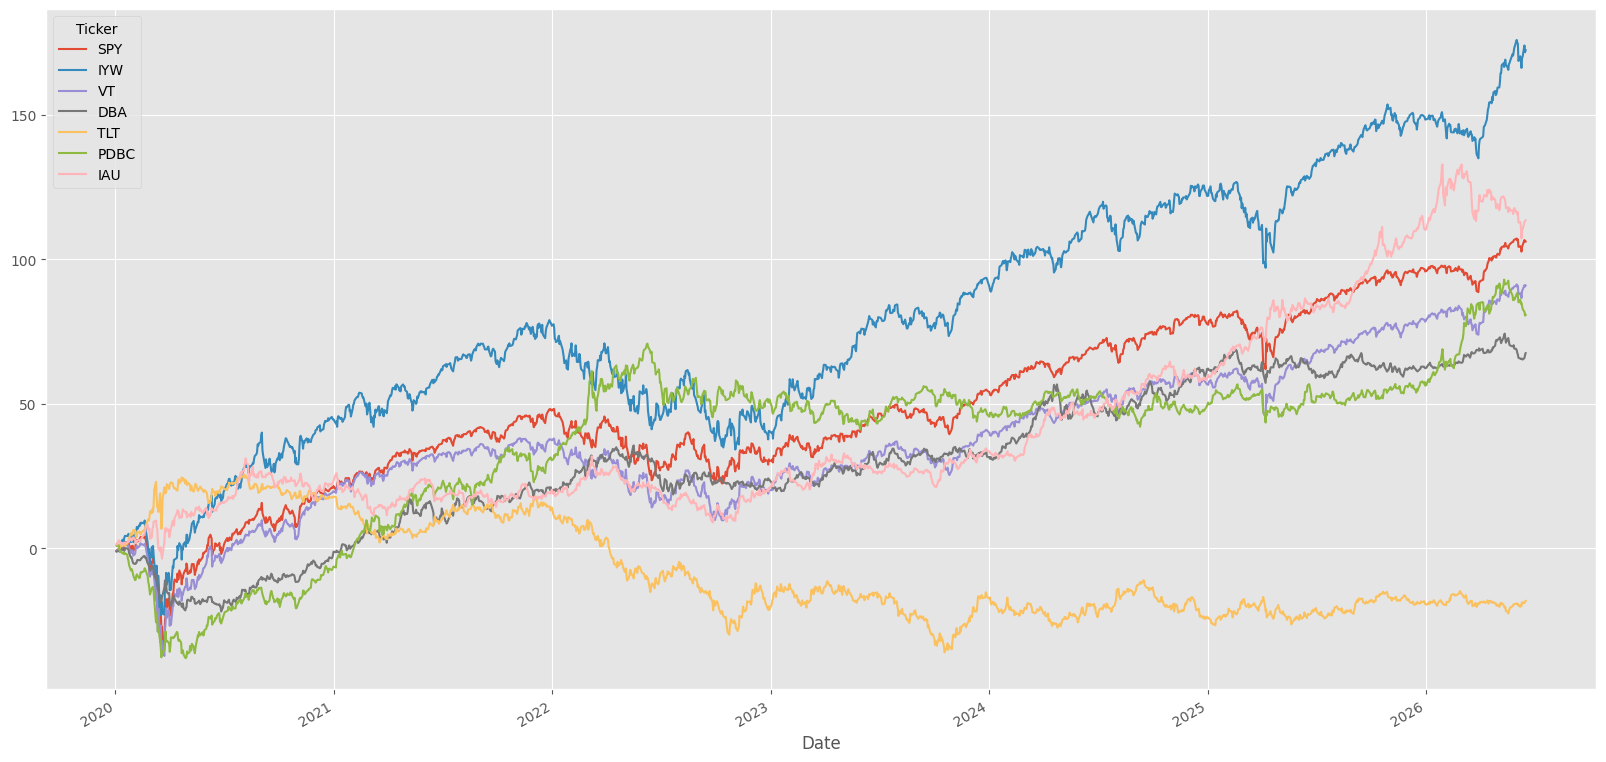

In [41]:
# Graficamos los retornos acumulados de todos los activos.
# 'figsize' definir el tamaño de la figura.
stock_d_cr.plot(figsize=(20,10))
